MAE : 14.83
R²  : 0.6747


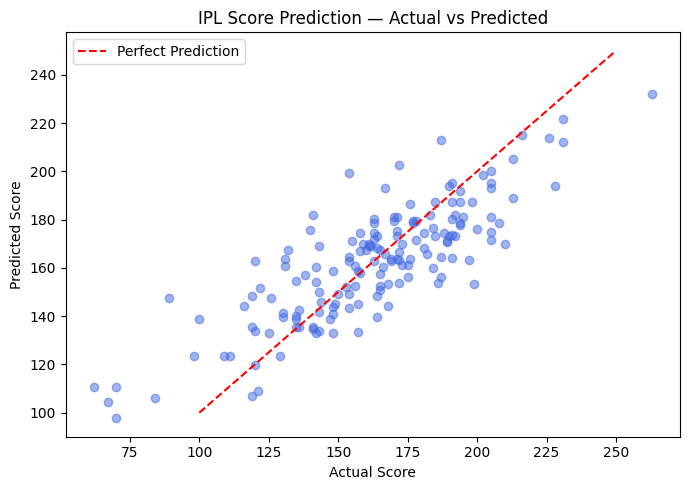

Score: 87/2 after 10 overs → Predicted Final: 171 runs
Score: 54/4 after 10 overs → Predicted Final: 127 runs
Score: 102/1 after 10 overs → Predicted Final: 192 runs


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score


deliveries = pd.read_csv('deliveries.csv')


first_10 = deliveries[deliveries['over'] <= 10]

df = first_10.groupby(['match_id', 'inning']).agg(
    runs_so_far  = ('total_runs', 'sum'),
    wickets_lost = ('player_dismissed', 'count'),
).reset_index()

df['run_rate']        = df['runs_so_far'] / 10
df['wickets_remaining'] = 10 - df['wickets_lost']

final = deliveries.groupby(['match_id','inning'])['total_runs'].sum().reset_index()
final.columns = ['match_id', 'inning', 'final_score']

df = df.merge(final, on=['match_id','inning'])
df = df[df['inning'] == 1].dropna()

X = df[['runs_so_far', 'wickets_lost', 'run_rate', 'wickets_remaining']]
y = df['final_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

preds = model.predict(X_test)
print(f"MAE : {mean_absolute_error(y_test, preds):.2f}")
print(f"R²  : {r2_score(y_test, preds):.4f}")

plt.figure(figsize=(7,5))
plt.scatter(y_test, preds, alpha=0.5, color='royalblue')
plt.plot([100, 250], [100, 250], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.title('IPL Score Prediction — Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.savefig('ipl_prediction.png', dpi=150)
plt.show()

def predict_score(runs, wickets):
    inp  = pd.DataFrame([[runs, wickets, runs/10, 10-wickets]],
                        columns=['runs_so_far', 'wickets_lost', 'run_rate', 'wickets_remaining'])
    pred = model.predict(inp)[0]
    print(f"Score: {runs}/{wickets} after 10 overs → Predicted Final: {round(pred)} runs")

predict_score(87, 2)
predict_score(54, 4)
predict_score(102, 1)

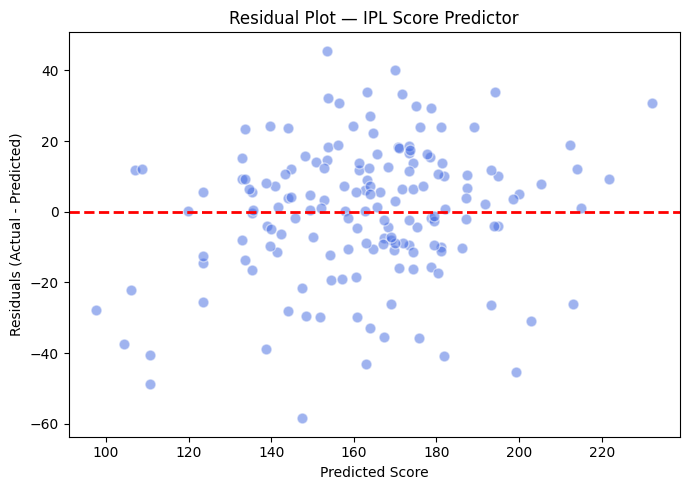

In [23]:
residuals = y_test - preds  # make sure variable name matches yours

plt.figure(figsize=(7, 5))
plt.scatter(preds, residuals, alpha=0.5, color='royalblue', edgecolors='white', s=60)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Predicted Score")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot — IPL Score Predictor")
plt.tight_layout()
plt.savefig('residual_plot.png', dpi=150)
plt.show()